In [ ]:
# NeuroLens: Features vs Samples Experiment

## Notebook 02b: Maximum Samples Pipeline (All 9 Datasets, All Regions)

**Author:** Ali | MSc Neuroscience | SPICED Academy Data Science Bootcamp  
**Date:** February 2026

---

## Motivation

In Notebook 02, we excluded GSE21138 (47% probe loss) and kept only PFC from GSE53987. This notebook tests the opposite: **maximize sample size (~615)** at the cost of fewer probes (~11,865).

| Version | Probes | Samples | Strategy |
|---------|--------|---------|----------|
| A (Notebook 02) | 22,277 → 20,049 | 419 → 414 | More features |
| B (this notebook) | ~11,865 → TBD | ~615 → TBD | More samples |

**Research question:** What matters more for psychiatric classification, gene features or sample size?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import os
from collections import Counter

print("Libraries loaded.")

Libraries loaded.


In [2]:
DATA_DIR = "../data/raw/"

def parse_geo_series_matrix(filepath):
    meta = {'sample_ids': [], 'sample_titles': []}
    open_func = gzip.open if filepath.endswith('.gz') else open

    with open_func(filepath, 'rt') as f:
        for line in f:
            if line.startswith('!Sample_geo_accession'):
                meta['sample_ids'] = [x.strip().strip('"') for x in line.split('\t')[1:]]
            elif line.startswith('!Sample_title'):
                meta['sample_titles'] = [x.strip().strip('"') for x in line.split('\t')[1:]]
            elif line.startswith('!Sample_characteristics_ch1'):
                parts = [x.strip().strip('"') for x in line.split('\t')[1:]]
                if ':' in parts[0]:
                    key = parts[0].split(':')[0].strip()
                    values = [x.split(':', 1)[1].strip() if ':' in x else x for x in parts]
                    meta[key] = values

    expr = pd.read_csv(filepath, sep='\t', comment='!', index_col=0, low_memory=False)
    expr = expr.apply(pd.to_numeric, errors='coerce')
    expr = expr.loc[expr.index.dropna()]
    expr.index = expr.index.astype(str)
    expr.index.name = 'probe_id'

    return meta, expr

print("Parser ready.")

Parser ready.


In [3]:
geo_files = {
    'GSE53987': os.path.join(DATA_DIR, 'GSE53987_series_matrix.txt.gz'),
    'GSE21138': os.path.join(DATA_DIR, 'GSE21138_series_matrix.txt'),
    'GSE17612': os.path.join(DATA_DIR, 'GSE17612_series_matrix.txt'),
    'GSE21935': os.path.join(DATA_DIR, 'GSE21935_series_matrix.txt'),
    'GSE54568': os.path.join(DATA_DIR, 'GSE54568_series_matrix.txt'),
    'GSE12649': os.path.join(DATA_DIR, 'GSE12649_series_matrix.txt'),
    'GSE5388':  os.path.join(DATA_DIR, 'GSE5388_series_matrix.txt'),
    'GSE5389':  os.path.join(DATA_DIR, 'GSE5389_series_matrix.txt'),
}

datasets = {}
all_meta = {}

for name, filepath in geo_files.items():
    meta, expr = parse_geo_series_matrix(filepath)
    datasets[name] = expr
    all_meta[name] = meta
    print(f"{name}: {expr.shape[0]:,} probes x {expr.shape[1]} samples")

# SMRI Altar C
altar_c_dir = os.path.join(DATA_DIR, 'study2/')
demo = pd.read_csv(os.path.join(altar_c_dir, "demoAnnTable2.txt"), sep='\t')
expr_smri = pd.read_csv(os.path.join(altar_c_dir, "rmaExpressionTable2.txt"), sep='\t', index_col=0)

sample_ids = [f"C-{i}" for i in range(1, len(demo) + 1)]
if 'Study_id' in expr_smri.columns:
    expr_smri = expr_smri.drop(columns=['Study_id'])
expr_smri.columns = sample_ids[:expr_smri.shape[1]]
expr_smri.index = expr_smri.index.astype(str)
expr_smri.index.name = 'probe_id'

datasets['SMRI_AltarC'] = expr_smri
all_meta['SMRI_AltarC'] = {
    'sample_ids': sample_ids,
    'diagnosis': demo['Axis_I_Primary_Dx'].tolist()
}

print(f"SMRI_AltarC: {expr_smri.shape[0]:,} probes x {expr_smri.shape[1]} samples")
print(f"\nTotal: {len(datasets)} datasets loaded.")

GSE53987: 54,675 probes x 205 samples
GSE21138: 30,061 probes x 59 samples
GSE17612: 54,675 probes x 51 samples
GSE21935: 54,675 probes x 42 samples
GSE54568: 54,675 probes x 30 samples
GSE12649: 22,283 probes x 102 samples
GSE5388: 22,283 probes x 61 samples
GSE5389: 22,283 probes x 21 samples
SMRI_AltarC: 22,283 probes x 44 samples

Total: 9 datasets loaded.


In [4]:
demo.columns.tolist()

['Database_ID',
 'Collection_type',
 'Age',
 'PMI',
 'Brain_PH',
 'Race',
 'Profile',
 'Left_Brain',
 'Sex',
 'Smoking_At_TOD',
 'Axis_I_Primary_Dx',
 'DSM_IV',
 'Suicide_Status',
 'Psychotic_Feature',
 'Lifetime_Alcohol_Use',
 'Lifetime_Drug_Use',
 'Rate_Of_Death',
 'Exacerbation',
 'Lifetime_Antipsychotics']

In [5]:
for name in all_meta:
    print(f"{name}: {list(all_meta[name].keys())}")

GSE53987: ['sample_ids', 'sample_titles', 'age', 'gender', 'race', 'pmi', 'ph', 'rin', 'tissue', 'disease state']
GSE21138: ['sample_ids', 'sample_titles', 'brain region', 'stage of illness [short doi=<5 yrs; intermediate doi=7-18yrs; long doi=>28 yrs]', 'Sex', 'age', 'tissue ph', 'pmi (hrs)', 'type of drug', 'drug dose (chlorpromazine equivalents)']
GSE17612: ['sample_ids', 'sample_titles', 'gender', 'age', 'post-mortem delay', 'ph']
GSE21935: ['sample_ids', 'sample_titles', 'gender', 'age', 'post-mortem delay', 'ph', 'disease state', 'tissue']
GSE54568: ['sample_ids', 'sample_titles', 'tissue', 'disease state']
GSE12649: ['sample_ids', 'sample_titles']
GSE5388: ['sample_ids', 'sample_titles', 'Disease_status', 'Age (years)', 'Gender', 'Age of onset (years)', 'Duration of illness (years)', 'Brain pH', 'Post mortem interval (hours)', 'Side of brain', 'Fluphenazine mg. Equivalents', 'Lithium treatment', 'Valproate treatment', 'Electroconvulsive therapy', 'Suicide', 'Drug abuse (ratings 

In [6]:
# Map Altar C diagnoses
dx_map = {
    'CONTROL': 'CTL', 'SCHIZ UNDIFF': 'SCZ', 'SCHIZ PARANOID': 'SCZ',
    'BP I': 'BD', 'BP II': 'BD',
    'DEPRESSIVE DISORDER': 'MDD', 'DEPRESSIVE DISORDER NOS': 'MDD'
}
demo['diagnosis'] = demo['Axis_I_Primary_Dx'].map(dx_map)

# Update SMRI metadata with all available fields
all_meta['SMRI_AltarC'] = {
    'sample_ids': sample_ids,
    'diagnosis': demo['diagnosis'].tolist(),
    'age': demo['Age'].tolist(),
    'sex': demo['Sex'].tolist(),
    'brain_ph': demo['Brain_PH'].tolist(),
    'pmi': demo['PMI'].tolist(),
    'race': demo['Race'].tolist(),
    'suicide': demo['Suicide_Status'].tolist()
}

demo['diagnosis'].value_counts()

diagnosis
SCZ    11
MDD    11
BD     11
CTL    11
Name: count, dtype: int64

In [7]:
all_labels = {}

# GSE53987 — ALL regions kept
labels = {}
for sid, d in zip(all_meta['GSE53987']['sample_ids'], all_meta['GSE53987']['disease state']):
    d = d.lower()
    if 'schizophrenia' in d:   labels[sid] = 'SCZ'
    elif 'bipolar' in d:       labels[sid] = 'BD'
    elif 'depressive' in d:    labels[sid] = 'MDD'
    elif 'control' in d:       labels[sid] = 'CTL'
all_labels['GSE53987'] = labels

# GSE21138
labels = {}
for sid, title in zip(all_meta['GSE21138']['sample_ids'], all_meta['GSE21138']['sample_titles']):
    t = title.lower()
    if 'control' in t:                       labels[sid] = 'CTL'
    elif 'schiz' in t or 'scz' in t:        labels[sid] = 'SCZ'
all_labels['GSE21138'] = labels

# GSE17612
labels = {}
for sid, title in zip(all_meta['GSE17612']['sample_ids'], all_meta['GSE17612']['sample_titles']):
    if '_Scz_' in title:       labels[sid] = 'SCZ'
    elif '_Control_' in title: labels[sid] = 'CTL'
all_labels['GSE17612'] = labels

# GSE21935
labels = {}
for sid, d in zip(all_meta['GSE21935']['sample_ids'], all_meta['GSE21935']['disease state']):
    if 'schizo' in d.lower():  labels[sid] = 'SCZ'
    elif 'control' in d.lower(): labels[sid] = 'CTL'
all_labels['GSE21935'] = labels

# GSE54568
labels = {}
for sid, d in zip(all_meta['GSE54568']['sample_ids'], all_meta['GSE54568']['disease state']):
    if 'mdd' in d.lower() or 'depress' in d.lower(): labels[sid] = 'MDD'
    elif 'control' in d.lower():                       labels[sid] = 'CTL'
all_labels['GSE54568'] = labels

# GSE12649
labels = {}
for sid, title in zip(all_meta['GSE12649']['sample_ids'], all_meta['GSE12649']['sample_titles']):
    if 'bipolar' in title.lower():         labels[sid] = 'BD'
    elif 'schizophrenia' in title.lower(): labels[sid] = 'SCZ'
    elif 'control' in title.lower():       labels[sid] = 'CTL'
all_labels['GSE12649'] = labels

# GSE5388
labels = {}
for sid, d in zip(all_meta['GSE5388']['sample_ids'], all_meta['GSE5388']['Disease_status']):
    if 'bipolar' in d.lower():   labels[sid] = 'BD'
    elif 'control' in d.lower(): labels[sid] = 'CTL'
all_labels['GSE5388'] = labels

# GSE5389
labels = {}
for sid, d in zip(all_meta['GSE5389']['sample_ids'], all_meta['GSE5389']['Disease_status']):
    if 'bipolar' in d.lower():   labels[sid] = 'BD'
    elif 'control' in d.lower(): labels[sid] = 'CTL'
all_labels['GSE5389'] = labels

# SMRI Altar C
labels = {}
for sid, d in zip(all_meta['SMRI_AltarC']['sample_ids'], all_meta['SMRI_AltarC']['diagnosis']):
    labels[sid] = d
all_labels['SMRI_AltarC'] = labels

# Summary
total = {'SCZ': 0, 'BD': 0, 'MDD': 0, 'CTL': 0}
for name in datasets:
    dx = Counter(all_labels[name].values())
    for cls in total:
        total[cls] += dx.get(cls, 0)
    print(f"{name:<15} SCZ={dx.get('SCZ',0):>3}  BD={dx.get('BD',0):>3}  "
          f"MDD={dx.get('MDD',0):>3}  CTL={dx.get('CTL',0):>3}  Total={sum(dx.values())}")

print(f"\n{'TOTAL':<15} SCZ={total['SCZ']:>3}  BD={total['BD']:>3}  "
      f"MDD={total['MDD']:>3}  CTL={total['CTL']:>3}  Total={sum(total.values())}")

GSE53987        SCZ= 48  BD= 52  MDD= 50  CTL= 55  Total=205
GSE21138        SCZ= 30  BD=  0  MDD=  0  CTL= 29  Total=59
GSE17612        SCZ= 28  BD=  0  MDD=  0  CTL= 23  Total=51
GSE21935        SCZ= 23  BD=  0  MDD=  0  CTL= 19  Total=42
GSE54568        SCZ=  0  BD=  0  MDD= 15  CTL= 15  Total=30
GSE12649        SCZ= 35  BD= 33  MDD=  0  CTL= 34  Total=102
GSE5388         SCZ=  0  BD= 30  MDD=  0  CTL= 31  Total=61
GSE5389         SCZ=  0  BD= 10  MDD=  0  CTL= 11  Total=21
SMRI_AltarC     SCZ= 11  BD= 11  MDD= 11  CTL= 11  Total=44

TOTAL           SCZ=175  BD=136  MDD= 76  CTL=228  Total=615


In [8]:
# Build unified metadata for all 615 samples
meta_rows = []

# GSE53987 — has age, sex, tissue (brain region), ph, pmi
for i, sid in enumerate(all_meta['GSE53987']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE53987',
        'diagnosis': all_labels['GSE53987'].get(sid),
        'age': all_meta['GSE53987']['age'][i],
        'sex': all_meta['GSE53987']['gender'][i],
        'brain_region': all_meta['GSE53987']['tissue'][i],
        'ph': all_meta['GSE53987']['ph'][i],
        'pmi': all_meta['GSE53987']['pmi'][i]
    })

# GSE21138 — has age, sex, ph, pmi
for i, sid in enumerate(all_meta['GSE21138']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE21138',
        'diagnosis': all_labels['GSE21138'].get(sid),
        'age': all_meta['GSE21138']['age'][i],
        'sex': all_meta['GSE21138']['Sex'][i],
        'brain_region': 'PFC (BA46)',
        'ph': all_meta['GSE21138']['tissue ph'][i],
        'pmi': all_meta['GSE21138']['pmi (hrs)'][i]
    })

# GSE17612 — has age, sex, ph, pmi
for i, sid in enumerate(all_meta['GSE17612']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE17612',
        'diagnosis': all_labels['GSE17612'].get(sid),
        'age': all_meta['GSE17612']['age'][i],
        'sex': all_meta['GSE17612']['gender'][i],
        'brain_region': 'PFC (BA10)',
        'ph': all_meta['GSE17612']['ph'][i],
        'pmi': all_meta['GSE17612']['post-mortem delay'][i]
    })

# GSE21935 — has age, sex, ph, pmi
for i, sid in enumerate(all_meta['GSE21935']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE21935',
        'diagnosis': all_labels['GSE21935'].get(sid),
        'age': all_meta['GSE21935']['age'][i],
        'sex': all_meta['GSE21935']['gender'][i],
        'brain_region': 'BA22',
        'ph': all_meta['GSE21935']['ph'][i],
        'pmi': all_meta['GSE21935']['post-mortem delay'][i]
    })

# GSE54568 — only tissue and diagnosis
for i, sid in enumerate(all_meta['GSE54568']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE54568',
        'diagnosis': all_labels['GSE54568'].get(sid),
        'age': None,
        'sex': None,
        'brain_region': 'PFC (BA9)',
        'ph': None,
        'pmi': None
    })

# GSE12649 — no metadata
for i, sid in enumerate(all_meta['GSE12649']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE12649',
        'diagnosis': all_labels['GSE12649'].get(sid),
        'age': None,
        'sex': None,
        'brain_region': 'PFC (BA46)',
        'ph': None,
        'pmi': None
    })

# GSE5388 — has age, sex, ph, pmi
for i, sid in enumerate(all_meta['GSE5388']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE5388',
        'diagnosis': all_labels['GSE5388'].get(sid),
        'age': all_meta['GSE5388']['Age (years)'][i],
        'sex': all_meta['GSE5388']['Gender'][i],
        'brain_region': 'PFC (BA46)',
        'ph': all_meta['GSE5388']['Brain pH'][i],
        'pmi': all_meta['GSE5388']['Post mortem interval (hours)'][i]
    })

# GSE5389 — has age, sex, ph, pmi
for i, sid in enumerate(all_meta['GSE5389']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'GSE5389',
        'diagnosis': all_labels['GSE5389'].get(sid),
        'age': all_meta['GSE5389']['Age (years)'][i],
        'sex': all_meta['GSE5389']['Gender'][i],
        'brain_region': 'OFC (BA11)',
        'ph': all_meta['GSE5389']['Brain pH'][i],
        'pmi': all_meta['GSE5389']['Post mortem interval (hours)'][i]
    })

# SMRI Altar C — has age, sex, ph, pmi
for i, sid in enumerate(all_meta['SMRI_AltarC']['sample_ids']):
    meta_rows.append({
        'sample_id': sid,
        'dataset': 'SMRI_AltarC',
        'diagnosis': all_labels['SMRI_AltarC'].get(sid),
        'age': all_meta['SMRI_AltarC']['age'][i],
        'sex': all_meta['SMRI_AltarC']['sex'][i],
        'brain_region': 'PFC (BA46)',
        'ph': all_meta['SMRI_AltarC']['brain_ph'][i],
        'pmi': all_meta['SMRI_AltarC']['pmi'][i]
    })

meta_df = pd.DataFrame(meta_rows)
meta_df.shape, meta_df['diagnosis'].value_counts(), meta_df.isna().sum()

((615, 8),
 diagnosis
 CTL    228
 SCZ    175
 BD     136
 MDD     76
 Name: count, dtype: int64,
 sample_id         0
 dataset           0
 diagnosis         0
 age             132
 sex             132
 brain_region      0
 ph              132
 pmi             132
 dtype: int64)

In [9]:
meta_df.groupby('dataset')[['age', 'sex', 'ph', 'pmi']].first()

,age,sex,ph,pmi
dataset,,,,
GSE12649,None,None,None,None
GSE17612,74,Male,6,4.5h
GSE21138,38,M,6.42,46
GSE21935,87,Female,6.5,14.5h
GSE5388,41,Male,6.60,39
GSE5389,31,Male,6.3,28
GSE53987,52,M,6.7,23.5
GSE54568,None,None,None,None
SMRI_AltarC,30,F,6.2,60


In [10]:
# Standardize sex
meta_df['sex'] = meta_df['sex'].replace({
    'Male': 'M', 'male': 'M', 'Female': 'F', 'female': 'F'
})

# Clean PMI (remove 'h' suffix, convert to numeric)
meta_df['pmi'] = meta_df['pmi'].astype(str).str.replace('h', '').str.strip()
meta_df['pmi'] = pd.to_numeric(meta_df['pmi'], errors='coerce')

# Convert age and ph to numeric
meta_df['age'] = pd.to_numeric(meta_df['age'], errors='coerce')
meta_df['ph'] = pd.to_numeric(meta_df['ph'], errors='coerce')

meta_df[['age', 'sex', 'ph', 'pmi']].describe(include='all')

,age,sex,ph,pmi
count,482.000000,483,481.000000,483.000000
unique,NaN,3,NaN,NaN
top,NaN,M,NaN,NaN
freq,NaN,293,NaN,NaN
mean,50.211618,NaN,6.434428,23.057019
std,16.287976,NaN,0.301053,13.998167
min,19.000000,NaN,5.600000,3.000000
25%,40.000000,NaN,6.200000,12.500000
50%,48.000000,NaN,6.440000,22.000000
75%,58.000000,NaN,6.600000,28.000000


In [11]:
meta_df['sex'].value_counts(dropna=False)

sex
M       293
F       189
None    132
91        1
Name: count, dtype: int64

In [12]:
meta_df[meta_df['sex'] == '91']

,sample_id,dataset,diagnosis,age,sex,brain_region,ph,pmi
274,GSM439788,GSE17612,CTL,NaN,91,PFC (BA10),NaN,6.3


In [13]:
# Check a few GSE17612 samples
for i in range(3):
    print(f"Title: {all_meta['GSE17612']['sample_titles'][i]}")
    print(f"  age: {all_meta['GSE17612']['age'][i]}")
    print(f"  gender: {all_meta['GSE17612']['gender'][i]}")
    print(f"  ph: {all_meta['GSE17612']['ph'][i]}")
    print(f"  pmi: {all_meta['GSE17612']['post-mortem delay'][i]}")
    print()

Title: S014_Scz_M_74
  age: 74
  gender: Male
  ph: 6
  pmi: 4.5h

Title: C017_Control_M_72
  age: 72
  gender: Male
  ph: 6.8
  pmi: 12h

Title: C011_Control_F_89
  age: 89
  gender: Female
  ph: 6.5
  pmi: 5h



In [14]:
# Find the problem sample
idx = meta_df[meta_df['sex'] == '91'].index[0]
sid = meta_df.loc[idx, 'sample_id']

# Find its position in GSE17612
pos = all_meta['GSE17612']['sample_ids'].index(sid)
print(f"Title: {all_meta['GSE17612']['sample_titles'][pos]}")
print(f"  age: {all_meta['GSE17612']['age'][pos]}")
print(f"  gender: {all_meta['GSE17612']['gender'][pos]}")
print(f"  ph: {all_meta['GSE17612']['ph'][pos]}")
print(f"  pmi: {all_meta['GSE17612']['post-mortem delay'][pos]}")

Title: C014_Control_M91
  age: 4.5h
  gender: 91
  ph: 
  pmi: 6.3


In [15]:
meta_df.loc[idx, 'age'] = 91
meta_df.loc[idx, 'sex'] = 'M'
meta_df.loc[idx, 'ph'] = 6.3
meta_df.loc[idx, 'pmi'] = np.nan

# Verify
meta_df.loc[idx]

sample_id        GSM439788
dataset           GSE17612
diagnosis              CTL
age                   91.0
sex                      M
brain_region    PFC (BA10)
ph                     6.3
pmi                    NaN
Name: 274, dtype: object

In [16]:
# GPL570 (5 datasets including GSE21138)
gpl570_probes = None
for name in ['GSE53987', 'GSE21138', 'GSE17612', 'GSE21935', 'GSE54568']:
    probes = set(datasets[name].index)
    print(f"  {name}: {len(probes):,} probes")
    gpl570_probes = probes if gpl570_probes is None else gpl570_probes.intersection(probes)
print(f"  GPL570 shared: {len(gpl570_probes):,}\n")

# GPL96 (4 datasets)
gpl96_probes = None
for name in ['GSE12649', 'GSE5388', 'GSE5389', 'SMRI_AltarC']:
    probes = set(datasets[name].index)
    print(f"  {name}: {len(probes):,} probes")
    gpl96_probes = probes if gpl96_probes is None else gpl96_probes.intersection(probes)
print(f"  GPL96 shared: {len(gpl96_probes):,}\n")

# Cross-platform
shared_probes = sorted(gpl570_probes.intersection(gpl96_probes))
print(f"Shared probes (all 9 datasets): {len(shared_probes):,}")
print(f"Notebook 02 had: 22,277")
print(f"Loss: {22277 - len(shared_probes):,} probes ({(22277 - len(shared_probes))/22277*100:.1f}%)")

  GSE53987: 54,675 probes
  GSE21138: 30,061 probes
  GSE17612: 54,675 probes
  GSE21935: 54,675 probes
  GSE54568: 54,675 probes
  GPL570 shared: 30,061

  GSE12649: 22,283 probes
  GSE5388: 22,283 probes
  GSE5389: 22,283 probes
  SMRI_AltarC: 22,283 probes
  GPL96 shared: 22,283

Shared probes (all 9 datasets): 11,865
Notebook 02 had: 22,277
Loss: 10,412 probes (46.7%)


In [17]:
# Restrict to shared probes
for name in datasets:
    before = datasets[name].shape[0]
    datasets[name] = datasets[name].loc[datasets[name].index.isin(shared_probes)]
    print(f"{name:<15} {before:>6,} → {datasets[name].shape[0]:,}")

# Merge all into one DataFrame
merged_expr = pd.concat([datasets[name] for name in datasets], axis=1)
merged_expr.shape, merged_expr.isna().sum().sum()

GSE53987        54,675 → 11,865
GSE21138        30,061 → 11,865
GSE17612        54,675 → 11,865
GSE21935        54,675 → 11,865
GSE54568        54,675 → 11,865
GSE12649        22,283 → 11,865
GSE5388         22,283 → 11,865
GSE5389         22,283 → 11,865
SMRI_AltarC     22,283 → 11,865


((11865, 615), 0)

In [18]:
already_log2 = ['GSE54568', 'SMRI_AltarC', 'GSE21138']
needs_clip = ['GSE21935', 'GSE12649']

for group_name, samples in meta_df.groupby('dataset')['sample_id']:
    cols = samples.tolist()
    before = merged_expr[cols].min().min(), merged_expr[cols].max().max()
    
    if group_name in already_log2:
        action = "skipped"
    elif group_name in needs_clip:
        merged_expr[cols] = np.log2(merged_expr[cols].clip(lower=1))
        action = "clip(1) + log2"
    else:
        merged_expr[cols] = np.log2(merged_expr[cols].clip(lower=1))
        action = "log2"
    
    after = merged_expr[cols].min().min(), merged_expr[cols].max().max()
    print(f"{group_name:<15} [{before[0]:>10.1f}, {before[1]:>10.1f}] → "
          f"[{after[0]:>6.2f}, {after[1]:>6.2f}]  ({action})")

GSE12649        [       0.0,      227.2] → [  0.00,   7.83]  (clip(1) + log2)
GSE17612        [       0.1,    14646.6] → [  0.00,  13.84]  (log2)
GSE21138        [       1.9,       13.0] → [  1.90,  12.97]  (skipped)
GSE21935        [    -319.2,     9802.7] → [  0.00,  13.26]  (clip(1) + log2)
GSE5388         [       8.5,    10867.5] → [  3.08,  13.41]  (log2)
GSE5389         [       5.9,     6044.4] → [  2.57,  12.56]  (log2)
GSE53987        [       4.8,    25856.1] → [  2.28,  14.66]  (log2)
GSE54568        [       2.8,       14.0] → [  2.81,  13.98]  (skipped)
SMRI_AltarC     [       2.2,       12.5] → [  2.16,  12.52]  (skipped)


In [ ]:
## Step 5: PCA Before ComBat

Visualize batch effects before correction. Each dataset should form its own cluster because of technical differences between labs, platforms, and processing methods.

In [5]:
import os
for f in os.listdir('../data/processed/'):
    print(f)

ml_ready.csv
ml_ready_max_samples.csv
patient_groups_max_samples.csv
.ipynb_checkpoints


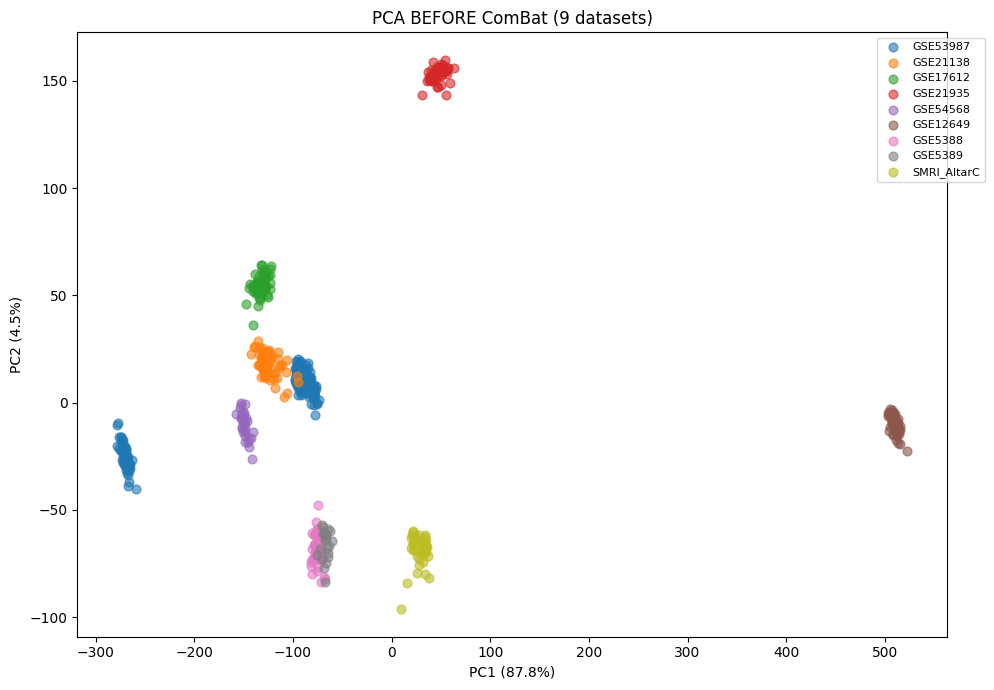

In [21]:
from sklearn.decomposition import PCA

pca_before = PCA(n_components=2)
pc_before = pca_before.fit_transform(merged_expr.T.values)

plt.figure(figsize=(10, 7))
for ds in meta_df['dataset'].unique():
    mask = (meta_df['dataset'] == ds).values
    plt.scatter(pc_before[mask, 0], pc_before[mask, 1], label=ds, alpha=0.6, s=40)

plt.xlabel(f"PC1 ({pca_before.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_before.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA BEFORE ComBat (9 datasets)")
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig('../figures/02b_pca_before_combat.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
!pip install neuroCombat --quiet

from neuroCombat import neuroCombat

print("neuroCombat imported successfully.")

neuroCombat imported successfully.


In [28]:
batch = meta_df.set_index('sample_id').loc[merged_expr.columns, 'dataset']
covariate = meta_df.set_index('sample_id').loc[merged_expr.columns, 'diagnosis']

covars_df = pd.DataFrame({
    'batch': batch,
    'diagnosis': covariate
}, index=merged_expr.columns)

combat_result = neuroCombat(
    dat=merged_expr.values,
    covars=covars_df,
    batch_col='batch',
    categorical_cols=['diagnosis']
)

combat_corrected = pd.DataFrame(
    combat_result['data'],
    index=merged_expr.index,
    columns=merged_expr.columns
)

combat_corrected.shape, combat_corrected.isna().sum().sum()

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


((11865, 615), 0)

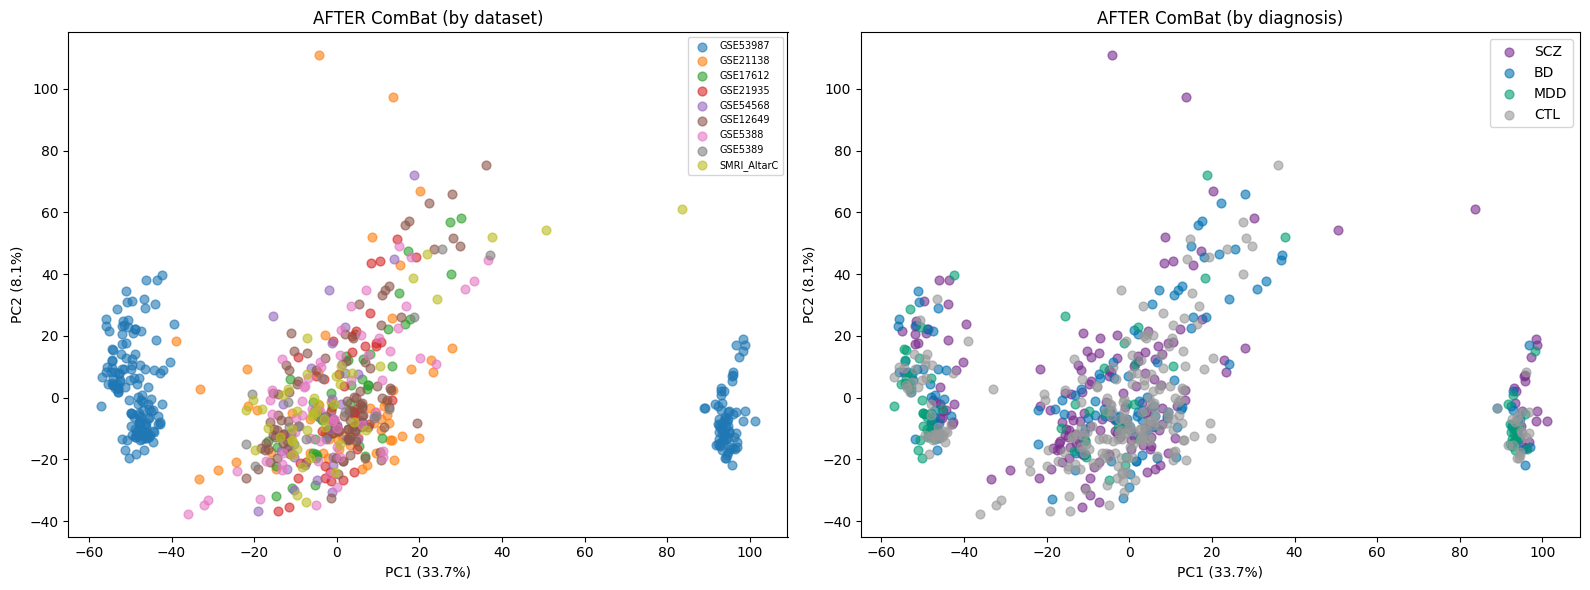

In [31]:
colors = {'SCZ': '#7B2D8E', 'BD': '#0072B2', 'MDD': '#009E73', 'CTL': '#999999'}

pca_after = PCA(n_components=2)
pc_after = pca_after.fit_transform(combat_corrected.T.values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By dataset
for ds in meta_df['dataset'].unique():
    mask = (meta_df['dataset'] == ds).values
    axes[0].scatter(pc_after[mask, 0], pc_after[mask, 1], label=ds, alpha=0.6, s=40)
axes[0].set_xlabel(f"PC1 ({pca_after.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_after.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("AFTER ComBat (by dataset)")
axes[0].legend(fontsize=7)

# By diagnosis
for dx in ['SCZ', 'BD', 'MDD', 'CTL']:
    mask = (meta_df['diagnosis'] == dx).values
    axes[1].scatter(pc_after[mask, 0], pc_after[mask, 1], label=dx, color=colors[dx], alpha=0.6, s=40)
axes[1].set_xlabel(f"PC1 ({pca_after.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_after.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("AFTER ComBat (by diagnosis)")
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/02b_pca_after_combat.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
## Step 8: Outlier Detection and Removal

Samples beyond 3 standard deviations on PC1 or PC2 indicate technical problems (RNA degradation, poor hybridization) that ComBat could not correct. 
These get removed.

In [32]:
pc1 = pc_after[:, 0]
pc2 = pc_after[:, 1]
pc1_z = (pc1 - pc1.mean()) / pc1.std()
pc2_z = (pc2 - pc2.mean()) / pc2.std()

outlier_mask = (np.abs(pc1_z) > 3) | (np.abs(pc2_z) > 3)
print(f"Outliers (>3 SD): {outlier_mask.sum()}")

meta_df[outlier_mask][['sample_id', 'dataset', 'diagnosis', 'brain_region']]

Outliers (>3 SD): 8


,sample_id,dataset,diagnosis,brain_region
240,GSM528866,GSE21138,SCZ,PFC (BA46)
247,GSM528873,GSE21138,SCZ,PFC (BA46)
252,GSM528878,GSE21138,SCZ,PFC (BA46)
374,GSM1319095,GSE54568,MDD,PFC (BA9)
413,GSM317411,GSE12649,BD,PFC (BA46)
435,GSM317433,GSE12649,BD,PFC (BA46)
443,GSM317441,GSE12649,CTL,PFC (BA46)
588,C-18,SMRI_AltarC,SCZ,PFC (BA46)


In [33]:
keep_mask = ~outlier_mask
combat_clean = combat_corrected.loc[:, meta_df[keep_mask]['sample_id']]
meta_df_clean = meta_df[keep_mask].reset_index(drop=True)

print(f"Removed: {outlier_mask.sum()} outliers")
print(f"Remaining: {combat_clean.shape[1]} samples")
print(f"\n{meta_df_clean['diagnosis'].value_counts()}")

Removed: 8 outliers
Remaining: 607 samples

diagnosis
CTL    227
SCZ    171
BD     134
MDD     75
Name: count, dtype: int64


In [ ]:
## Step 9: Low-Variance Probe Filtering

Probes with near-zero variance carry no useful signal for classification. 
Remove the bottom 10th percentile by variance. Same threshold used in Notebook 02.

In [34]:
probe_var = combat_clean.var(axis=1)
threshold = probe_var.quantile(0.10)

combat_filtered = combat_clean.loc[probe_var >= threshold]

print(f"Before: {combat_clean.shape[0]:,} probes")
print(f"Threshold (10th percentile): {threshold:.4f}")
print(f"Removed: {combat_clean.shape[0] - combat_filtered.shape[0]:,}")
print(f"Kept: {combat_filtered.shape[0]:,}")
print(f"\nFinal: {combat_filtered.shape[0]:,} probes x {combat_filtered.shape[1]} samples")

Before: 11,865 probes
Threshold (10th percentile): 0.1774
Removed: 1,187
Kept: 10,678

Final: 10,678 probes x 607 samples


In [ ]:
## Step 10: Transpose to ML Format

Convert from genomics format (probes × samples) to ML format (samples × features).
Merge with metadata table to include diagnosis, brain region, dataset, age, sex, pH, and PMI alongside the probe expression values.

In [35]:
df_ml = combat_filtered.T.copy()
df_ml.index.name = 'sample_id'

# Merge with metadata
meta_indexed = meta_df_clean.set_index('sample_id')
df_ml = df_ml.join(meta_indexed)

df_ml.shape, df_ml[['diagnosis', 'brain_region', 'dataset', 'age', 'sex', 'ph', 'pmi']].head()

((607, 10685),
            diagnosis brain_region   dataset   age sex   ph   pmi
 sample_id                                                       
 GSM1304852        BD  hippocampus  GSE53987  52.0   M  6.7  23.5
 GSM1304853        BD  hippocampus  GSE53987  50.0   F  6.4  11.7
 GSM1304854        BD  hippocampus  GSE53987  28.0   F  6.3  22.3
 GSM1304855        BD  hippocampus  GSE53987  55.0   F  6.4  17.5
 GSM1304856        BD  hippocampus  GSE53987  58.0   M  6.8  27.7)

In [ ]:
## Step 11: Patient Group IDs and Export

GSE53987 has ~68 patients each measured in 3 brain regions (PFC, hippocampus, striatum). These are NOT independent samples. In Notebook 03, we need GroupKFold cross-validation to keep all samples from the same patient in the same fold.

We assign patient group IDs here:
- GSE53987: samples from the same patient across regions share one group ID
- All other datasets: each sample gets its own unique group ID (1 patient = 1 sample)

In [36]:
# Patient group mapping for GSE53987 (same patient across 3 regions)
# Other datasets: each sample is its own group
gse53987_samples = meta_df_clean[meta_df_clean['dataset'] == 'GSE53987']['sample_id'].tolist()
region_samples = {}
for sid in gse53987_samples:
    region = meta_df_clean.loc[meta_df_clean['sample_id'] == sid, 'brain_region'].values[0]
    if region not in region_samples:
        region_samples[region] = []
    region_samples[region].append(sorted(gse53987_samples))

# Assign patient groups
patient_groups = {}
regions_list = sorted(region_samples.keys())
for region in regions_list:
    region_samples[region] = sorted(meta_df_clean[
        (meta_df_clean['dataset'] == 'GSE53987') & 
        (meta_df_clean['brain_region'] == region)
    ]['sample_id'].tolist())

n_per_region = len(region_samples[regions_list[0]])
for i in range(n_per_region):
    pid = f"GSE53987_P{i+1:03d}"
    for region in regions_list:
        if i < len(region_samples[region]):
            patient_groups[region_samples[region][i]] = pid

# All other samples: unique group
for sid in meta_df_clean['sample_id']:
    if sid not in patient_groups:
        patient_groups[sid] = sid

df_ml['patient_group'] = df_ml.index.map(patient_groups)

print(f"Total patient groups: {df_ml['patient_group'].nunique()}")
print(f"GSE53987 patients: {len(set(v for v in patient_groups.values() if v.startswith('GSE53987')))}")

Total patient groups: 471
GSE53987 patients: 69


In [37]:
# Export ML-ready data
output_path = '../data/processed/ml_ready_max_samples.csv'
df_ml.to_csv(output_path)
file_size = os.path.getsize(output_path) / (1024 * 1024)
print(f"Exported: {output_path} ({file_size:.1f} MB)")

# Export patient groups separately (for GroupKFold)
group_df = df_ml[['patient_group', 'dataset', 'brain_region', 'diagnosis']].copy()
group_path = '../data/processed/patient_groups_max_samples.csv'
group_df.to_csv(group_path)
print(f"Exported: {group_path}")

Exported: ../data/processed/ml_ready_max_samples.csv (112.2 MB)
Exported: ../data/processed/patient_groups_max_samples.csv


In [ ]:
## Step 12: EDA on Preprocessed Data

In [38]:
df_ml['diagnosis'].value_counts(normalize=True).round(3)

diagnosis
CTL    0.374
SCZ    0.282
BD     0.221
MDD    0.124
Name: proportion, dtype: float64

In [39]:
df_ml.dtypes.value_counts()

float64    10681
object         5
Name: count, dtype: int64

In [40]:
(df_ml.columns[:10].tolist())

['1007_s_at',
 '1053_at',
 '117_at',
 '121_at',
 '1255_g_at',
 '1294_at',
 '1320_at',
 '1431_at',
 '1438_at',
 '1487_at']

In [52]:
df_ml.shape

(607, 10686)

In [57]:
df_ml.head(10)

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1320_at,1431_at,1438_at,1487_at,...,AFFX-ThrX-M_at,AFFX-TrpnX-5_at,dataset,diagnosis,age,sex,brain_region,ph,pmi,patient_group
sample_id,,,,,,,,,,,,,,,,,,,,,
GSM1304852,8.792186,4.409980,3.957047,6.573829,3.470725,5.032067,2.565003,3.601286,3.943483,5.640772,...,5.136428,2.402256,GSE53987,BD,52.0,M,hippocampus,6.7,23.5,GSE53987_P001
GSM1304853,8.571978,4.336751,3.855544,6.816533,3.908824,5.146817,2.820035,3.710125,4.381397,5.825937,...,5.033782,2.259684,GSE53987,BD,50.0,F,hippocampus,6.4,11.7,GSE53987_P002
GSM1304854,8.514104,4.728483,3.942634,6.679059,3.714725,5.018816,2.812683,3.611670,4.585971,5.797797,...,4.845356,2.206989,GSE53987,BD,28.0,F,hippocampus,6.3,22.3,GSE53987_P003
GSM1304855,8.187310,4.760023,3.677227,6.687386,3.491800,4.967875,2.670872,3.640152,4.367384,5.653374,...,5.253777,2.234428,GSE53987,BD,55.0,F,hippocampus,6.4,17.5,GSE53987_P004
GSM1304856,8.422636,4.571309,4.112292,6.632098,3.386848,5.067802,2.839794,3.590785,3.961943,5.647661,...,5.544517,2.429635,GSE53987,BD,58.0,M,hippocampus,6.8,27.7,GSE53987_P005
GSM1304857,8.509901,4.196777,4.015278,6.705519,3.964755,5.164100,2.687912,3.583896,4.187716,5.744429,...,5.685903,2.413283,GSE53987,BD,28.0,M,hippocampus,6.2,27.4,GSE53987_P006
GSM1304858,8.270006,4.543845,4.072755,6.760440,3.557744,5.065973,2.917878,3.698426,3.929459,5.506181,...,5.210719,2.305638,GSE53987,BD,49.0,F,hippocampus,6.7,21.5,GSE53987_P007
GSM1304859,8.705140,4.306738,3.775914,6.609503,3.345447,5.218318,2.761653,3.602851,3.907577,6.000544,...,5.272324,2.462992,GSE53987,BD,42.0,F,hippocampus,6.5,31.2,GSE53987_P008
GSM1304860,8.166860,4.247085,4.055038,6.680381,3.797506,4.997499,2.770121,3.653088,4.191547,5.717099,...,5.793869,2.345525,GSE53987,BD,43.0,F,hippocampus,6.7,31.9,GSE53987_P009


In [54]:
df_ml.tail()

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1320_at,1431_at,1438_at,1487_at,...,AFFX-ThrX-M_at,AFFX-TrpnX-5_at,dataset,diagnosis,age,sex,brain_region,ph,pmi,patient_group
sample_id,,,,,,,,,,,,,,,,,,,,,
C-40,9.271377,5.329586,4.540985,6.304804,3.801943,5.076177,2.637958,3.420202,3.932291,5.385327,...,3.494043,2.003597,SMRI_AltarC,CTL,35.0,F,PFC (BA46),5.8,40.0,C-40
C-41,8.805085,4.480296,4.852275,7.245534,4.390189,5.553657,3.911401,4.155079,5.605794,6.952568,...,4.777478,3.204717,SMRI_AltarC,MDD,55.0,F,PFC (BA46),5.8,28.0,C-41
C-42,7.866844,4.860550,4.473413,6.337020,4.398147,5.465344,3.942422,4.464182,5.050326,6.196575,...,5.239995,3.304689,SMRI_AltarC,MDD,30.0,F,PFC (BA46),6.0,33.0,C-42
C-43,8.384812,4.780423,4.517517,6.485916,4.235833,4.909609,3.576219,4.485131,4.730545,5.538328,...,4.721388,3.084805,SMRI_AltarC,MDD,45.0,M,PFC (BA46),6.4,28.0,C-43
C-44,8.579298,4.840237,4.210438,6.358068,4.056763,5.339568,4.127078,4.333409,4.479767,5.215655,...,5.043767,2.988435,SMRI_AltarC,CTL,30.0,F,PFC (BA46),6.2,42.0,C-44


In [61]:
df_ml.columns

Index(['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at',
       '1320_at', '1431_at', '1438_at', '1487_at',
       ...
       'AFFX-ThrX-M_at', 'AFFX-TrpnX-5_at', 'dataset', 'diagnosis', 'age',
       'sex', 'brain_region', 'ph', 'pmi', 'patient_group'],
      dtype='object', length=10686)

In [41]:
df_ml.describe()

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1320_at,1431_at,1438_at,1487_at,...,AFFX-r2-Bs-phe-M_at,AFFX-r2-Bs-thr-3_s_at,AFFX-r2-Bs-thr-5_s_at,AFFX-r2-Bs-thr-M_s_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-5_at,age,ph,pmi
count,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,...,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,479.000000,478.000000,478.000000
mean,8.730950,5.192765,4.490293,7.050870,4.454708,5.393544,3.303208,4.248525,4.853553,6.154012,...,4.127870,4.815383,4.851296,5.000034,4.226238,4.204924,2.762503,50.365344,6.436506,22.916820
std,0.570216,0.471549,0.884233,0.486595,0.991301,0.554183,0.535925,0.472154,0.631674,0.595340,...,0.865022,1.008622,0.738445,0.978520,0.739171,0.828235,0.573687,16.377417,0.299506,13.877771
min,7.040350,3.437728,2.872269,5.485171,1.541347,3.924900,1.390625,2.673869,3.237827,4.572992,...,2.026391,2.809519,0.578310,1.772476,2.377878,2.274630,0.923895,19.000000,5.600000,3.000000
25%,8.323316,4.850900,3.929619,6.684731,3.741895,4.951132,2.870356,4.001546,4.446490,5.715270,...,3.486065,4.254662,4.486475,4.483410,3.604487,3.690738,2.307645,40.000000,6.200000,12.500000
50%,8.621512,5.173992,4.349460,6.949809,4.313622,5.265327,3.240112,4.293515,4.697213,6.026348,...,4.130715,4.852901,4.891897,5.068337,4.163674,4.081151,2.648550,48.000000,6.440000,22.000000
75%,9.176400,5.516499,4.691538,7.459492,4.954039,5.797435,3.544580,4.554618,5.359569,6.648323,...,4.723857,5.563643,5.295091,5.725132,4.808749,4.811020,3.160103,58.000000,6.600000,28.000000
max,10.358678,7.189434,10.647337,8.392118,9.910790,7.647732,5.082097,6.611400,7.846151,8.140881,...,6.921440,9.216036,7.790709,8.017152,6.355974,7.958974,5.063569,97.000000,7.300000,84.000000


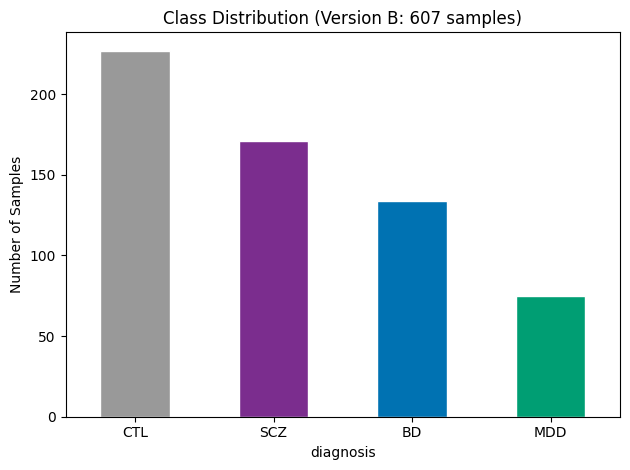

In [42]:
### Class Distribution

df_ml['diagnosis'].value_counts().plot(kind='bar', color=['#999999', '#7B2D8E', '#0072B2', '#009E73'],
                                        edgecolor='white')
plt.ylabel('Number of Samples')
plt.title('Class Distribution (Version B: 607 samples)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/02b_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

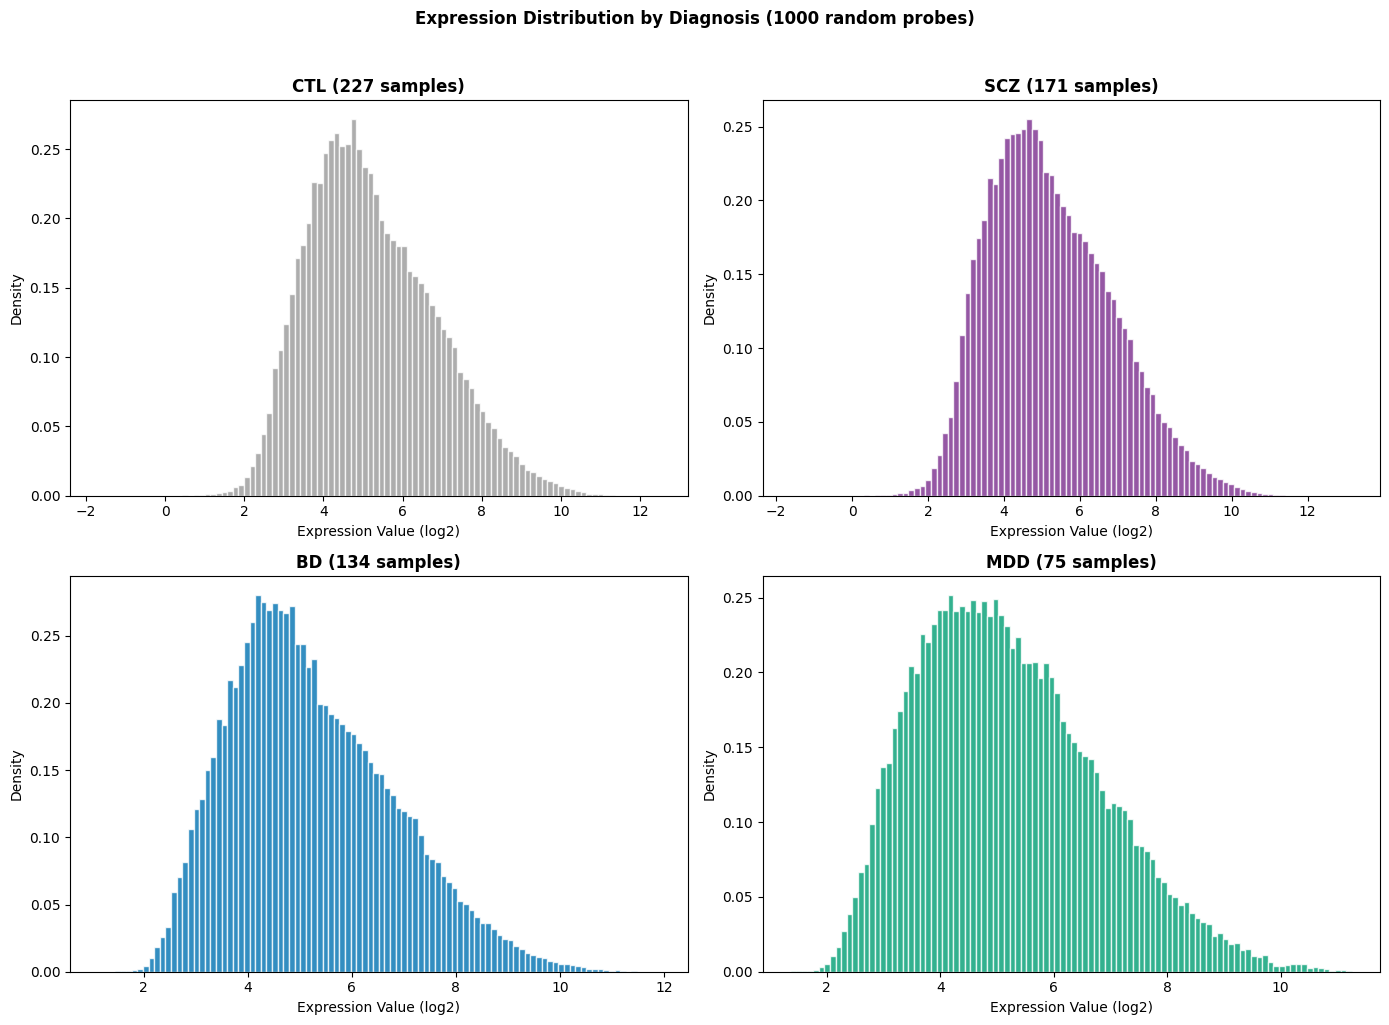

In [45]:
### Expression Distribution by Diagnosis


probe_cols = [c for c in df_ml.columns if c not in ['diagnosis', 'brain_region', 'dataset', 'age', 'sex', 'ph', 'pmi', 'patient_group']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
np.random.seed(42)
random_probes = np.random.choice(probe_cols, size=1000, replace=False)

for ax, dx in zip(axes.flatten(), ['CTL', 'SCZ', 'BD', 'MDD']):
    vals = df_ml[df_ml['diagnosis'] == dx][random_probes].values.flatten()
    ax.hist(vals, bins=100, color=colors[dx], edgecolor='white', alpha=0.8, density=True)
    ax.set_title(f"{dx} ({(df_ml['diagnosis']==dx).sum()} samples)", fontweight='bold')
    ax.set_xlabel('Expression Value (log2)')
    ax.set_ylabel('Density')

plt.suptitle('Expression Distribution by Diagnosis (1000 random probes)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/02b_expression_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

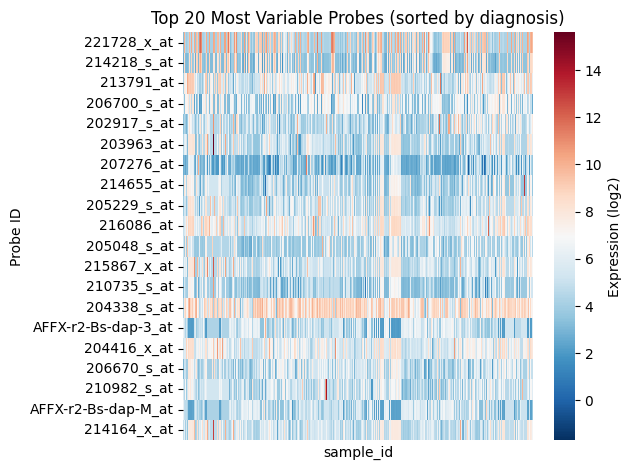

In [44]:
### Top 20 Most Variable Probes

top20 = df_ml[probe_cols].var().nlargest(20).index.tolist()

df_sorted = df_ml.sort_values('diagnosis')
sns.heatmap(df_sorted[top20].T, cmap='RdBu_r', xticklabels=False,
            cbar_kws={'label': 'Expression (log2)'})
plt.title('Top 20 Most Variable Probes (sorted by diagnosis)')
plt.ylabel('Probe ID')
plt.tight_layout()
plt.savefig('../figures/02b_top20_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Top 20 Most Variable Probes — Heatmap

The 20 probes with the highest variance across all 607 samples. Samples sorted by diagnosis (BD → CTL → MDD → SCZ). Color shifts across diagnosis groups suggest potential discriminatory signal for the classifier.

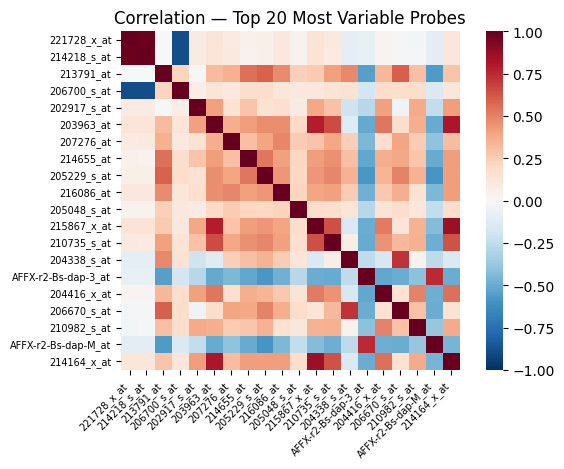

In [46]:
sns.heatmap(df_ml[top20].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlation — Top 20 Most Variable Probes')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('../figures/02b_top20_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Top 20 Most Variable Probes — Heatmap

The 20 probes with the highest variance across all 607 samples. Samples sorted by diagnosis (BD → CTL → MDD → SCZ left to right).

**Color scale:** Red = high expression, Blue = low expression. Color shifts across diagnosis groups suggest potential discriminatory signal for the classifier. AFFX probes are Affymetrix quality control probes, not biological genes.

In [ ]:
## Step 9: Low-Variance Probe Filtering

Probes with near-zero variance carry no useful signal for classification. Remove the bottom 10th percentile by variance. Same threshold used in Notebook 02.

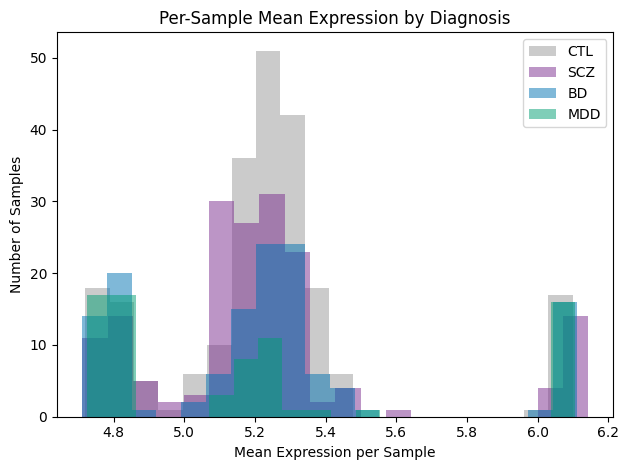

In [47]:
sample_means = df_ml[probe_cols].mean(axis=1)

for dx in ['CTL', 'SCZ', 'BD', 'MDD']:
    mask = df_ml['diagnosis'] == dx
    plt.hist(sample_means[mask], bins=20, alpha=0.5, label=dx, color=colors[dx])

plt.xlabel('Mean Expression per Sample')
plt.ylabel('Number of Samples')
plt.title('Per-Sample Mean Expression by Diagnosis')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/02b_sample_means.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Per-Sample Mean Expression by Diagnosis

Each bar represents one sample's average expression across all 10,678 probes.

**Color:** Grey = CTL, Purple = SCZ, Blue = BD, Green = MDD.

All groups should center around the same mean after ComBat. A separate cluster around 6.0 contains 69 striatum samples from GSE53987. This separation is biological (striatum expresses genes differently from cortex), not a batch effect. ComBat correctly preserved this real tissue difference.

In [48]:
high_mean = sample_means[sample_means > 5.8]
meta_df_clean.set_index('sample_id').loc[high_mean.index, 'dataset'].value_counts()

dataset
GSE53987    69
Name: count, dtype: int64

In [49]:
meta_df_clean.set_index('sample_id').loc[high_mean.index, 'brain_region'].value_counts()

brain_region
Associative striatum    69
Name: count, dtype: int64

In [51]:
print("=" * 60)
print("NOTEBOOK 02b: FEATURES VS SAMPLES - FINAL SUMMARY")
print("=" * 60)
print(f"\n  Datasets:          {meta_df_clean['dataset'].nunique()}")
print(f"  Total samples:     {df_ml.shape[0]}")
print(f"  Probe features:    {len(probe_cols)}")
print(f"  Patient groups:    {df_ml['patient_group'].nunique()} (for GroupKFold)")
print(f"  Brain regions:     {meta_df_clean['brain_region'].nunique()}")

print(f"\n  SCZ: {(df_ml['diagnosis']=='SCZ').sum()}")
print(f"  BD:  {(df_ml['diagnosis']=='BD').sum()}")
print(f"  MDD: {(df_ml['diagnosis']=='MDD').sum()}")
print(f"  CTL: {(df_ml['diagnosis']=='CTL').sum()}")

print(f"\n  COMPARISON WITH NOTEBOOK 02:")
print(f"  {'':>25} {'Notebook 02':>15} {'This Notebook':>15}")
print(f"  {'Samples':>25} {'414':>15} {df_ml.shape[0]:>15}")
print(f"  {'Probe features':>25} {'20,049':>15} {len(probe_cols):>15,}")
print(f"  {'Datasets':>25} {'8':>15} {'9':>15}")
print(f"  {'GSE53987 regions':>25} {'PFC only':>15} {'all 3':>15}")
print(f"  {'GroupKFold needed':>25} {'No':>15} {'Yes':>15}")

print(f"\n  Output files:")
print(f"    ml_ready_max_samples.csv")
print(f"    patient_groups_max_samples.csv")
print("=" * 60)

NOTEBOOK 02b: FEATURES VS SAMPLES - FINAL SUMMARY

  Datasets:          9
  Total samples:     607
  Probe features:    10678
  Patient groups:    471 (for GroupKFold)
  Brain regions:     8

  SCZ: 171
  BD:  134
  MDD: 75
  CTL: 227

  COMPARISON WITH NOTEBOOK 02:
                                Notebook 02   This Notebook
                    Samples             414             607
             Probe features          20,049          10,678
                   Datasets               8               9
           GSE53987 regions        PFC only           all 3
          GroupKFold needed              No             Yes

  Output files:
    ml_ready_max_samples.csv
    patient_groups_max_samples.csv
